In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pickle

# from EDA 
FLAT_SENSORS = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

USEFUL_SENSORS = ['s2','s3','s4','s7','s8','s9','s11',
                  's12','s13','s14','s15','s17','s20','s21']

col_names = ['engine_id', 'cycle',
             'setting1', 'setting2', 'setting3',
             's1','s2','s3','s4','s5','s6','s7',
             's8','s9','s10','s11','s12','s13',
             's14','s15','s16','s17','s18','s19',
             's20','s21']

In [3]:
def load_data(filepath):
    df = pd.read_csv(filepath,
                     sep='\s+',
                     header=None,
                     names=col_names)
    
    # Drop flat sensors immediately on load
    df.drop(columns=FLAT_SENSORS, inplace=True)
    
    return df

train_df = load_data('../data/raw/train_FD001.txt')
test_df  = load_data('../data/raw/test_FD001.txt')

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (20631, 19)
Test shape:  (13096, 19)


In [4]:
def add_rul(df):
    max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycle']
    df = df.merge(max_cycles, on='engine_id')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop(columns=['max_cycle'], inplace=True)
    return df

train_df = add_rul(train_df)
print(train_df[['engine_id', 'cycle', 'RUL']].head(10))

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187
5          1      6  186
6          1      7  185
7          1      8  184
8          1      9  183
9          1     10  182


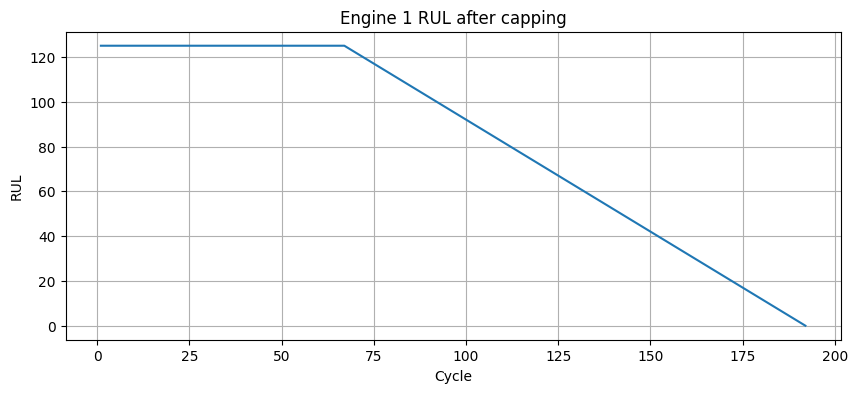

In [5]:
# Cap RUL at 125 cycles
RUL_CAP = 125

train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

# Plot one engine to see the effect
engine_1 = train_df[train_df['engine_id'] == 1]
plt.figure(figsize=(10,4))
plt.plot(engine_1['cycle'], engine_1['RUL'])
plt.title('Engine 1 RUL after capping')
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.grid(True)
plt.show()

In [6]:
scaler = MinMaxScaler()

# CRITICAL: fit ONLY on training data
scaler.fit(train_df[USEFUL_SENSORS])

# Transform both train and test using the same scaler
train_df[USEFUL_SENSORS] = scaler.transform(train_df[USEFUL_SENSORS])
test_df[USEFUL_SENSORS]  = scaler.transform(test_df[USEFUL_SENSORS])

# Save the scaler — you will need this exact object in production
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved.")
print(train_df[USEFUL_SENSORS].describe().round(3))

Scaler saved.
              s2         s3         s4         s7         s8         s9  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.443      0.425      0.450      0.566      0.298      0.195   
std        0.151      0.134      0.152      0.143      0.108      0.099   
min        0.000      0.000      0.000      0.000      0.000      0.000   
25%        0.336      0.332      0.339      0.477      0.227      0.141   
50%        0.431      0.416      0.435      0.578      0.288      0.175   
75%        0.539      0.509      0.545      0.670      0.364      0.214   
max        1.000      1.000      1.000      1.000      1.000      1.000   

             s11        s12        s13        s14        s15        s17  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.411      0.581      0.318      0.226      0.451      0.434   
std        0.159      0.157      0.106      0.098      0.144      0.129   
min       

In [7]:
# The RUL file has one value per engine — the true RUL at the cutoff point
test_rul = pd.read_csv('../data/raw/RUL_FD001.txt',
                        header=None,
                        names=['RUL'])

# Get the last cycle for each test engine
test_last_cycle = test_df.groupby('engine_id').last().reset_index()

# The ground truth RUL for the last cycle of each test engine
test_last_cycle['true_RUL'] = test_rul['RUL'].values

print(test_last_cycle[['engine_id', 'cycle', 'true_RUL']].head(10))

   engine_id  cycle  true_RUL
0          1     31       112
1          2     49        98
2          3    126        69
3          4    106        82
4          5     98        91
5          6    105        93
6          7    160        91
7          8    166        95
8          9     55       111
9         10    192        96


In [8]:
train_df.to_csv('../data/processed_train.csv', index=False)
test_df.to_csv('../data/processed_test.csv', index=False)
test_last_cycle.to_csv('../data/test_labels.csv', index=False)

print("All processed files saved.")

All processed files saved.
